# Лабораторна робота 6

## Агентна система підтримки прийняття рішень для вибору режиму прання


In [16]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display, clear_output
import ipywidgets as widgets

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 1. Завантаження датасету

In [17]:
DATASET_DIR = Path("clothes_dataset")
image_extensions = [".jpg", ".jpeg", ".png", ".webp"]

rows = []

for class_dir in DATASET_DIR.iterdir():
    if class_dir.is_dir():
        for image_path in class_dir.iterdir():
            if image_path.suffix.lower() in image_extensions:
                rows.append({
                    "clothes_class": class_dir.name,
                    "image_path": image_path
                })

dataset = pd.DataFrame(rows)

print("Кількість зображень у датасеті:", len(dataset))
print("Кількість класів одягу:", dataset["clothes_class"].nunique())

dataset.head()

Кількість зображень у датасеті: 7500
Кількість класів одягу: 15


,clothes_class,image_path
0,Blazer,clothes_dataset\Blazer\001912_280188340_thumbn...
1,Blazer,clothes_dataset\Blazer\002800_158897544_thumbn...
2,Blazer,clothes_dataset\Blazer\00342aff-ba69-4cf2-ae62...
3,Blazer,clothes_dataset\Blazer\00b8048d-635e-4e56-b182...
4,Blazer,clothes_dataset\Blazer\010805_191610748_thumbn...


In [18]:
class_counts = dataset["clothes_class"].value_counts()
display(class_counts.to_frame("Кількість зображень"))

,Кількість зображень
clothes_class,
Blazer,500
Celana_Panjang,500
Celana_Pendek,500
Gaun,500
Hoodie,500
Jaket,500
Jaket_Denim,500
Jaket_Olahraga,500
Jeans,500


## 2. Опис класів одягу

In [19]:
clothes_info = {
    "Blazer": ["піджак", "делікатна тканина", 8, 30, 500],
    "Celana_Panjang": ["довгі штани", "бавовна / синтетика", 4, 40, 900],
    "Celana_Pendek": ["шорти", "бавовна", 3, 40, 1000],
    "Gaun": ["сукня", "делікатна тканина", 9, 30, 400],
    "Hoodie": ["худі", "бавовна / синтетика", 5, 40, 800],
    "Jaket": ["куртка", "синтетика", 6, 30, 600],
    "Jaket_Denim": ["джинсова куртка", "денім", 3, 50, 1000],
    "Jaket_Olahraga": ["спортивна куртка", "синтетика", 5, 30, 700],
    "Jeans": ["джинси", "денім", 3, 50, 1000],
    "Kaos": ["футболка", "бавовна", 3, 40, 1000],
    "Kemeja": ["сорочка", "бавовна / тонка тканина", 5, 40, 800],
    "Mantel": ["пальто", "верхній одяг", 8, 30, 400],
    "Polo": ["поло", "бавовна", 4, 40, 900],
    "Rok": ["спідниця", "делікатна тканина", 8, 30, 500],
    "Sweter": ["светр", "вовна / трикотаж", 9, 30, 400]
}

clothes_table = pd.DataFrame([
    {
        "Клас": key,
        "Тип речі": value[0],
        "Тканина": value[1],
        "Делікатність": value[2],
        "Базова температура": value[3],
        "Базовий віджим": value[4]
    }
    for key, value in clothes_info.items()
])

display(clothes_table)

,Клас,Тип речі,Тканина,Делікатність,Базова температура,Базовий віджим
0,Blazer,піджак,делікатна тканина,8,30,500
1,Celana_Panjang,довгі штани,бавовна / синтетика,4,40,900
2,Celana_Pendek,шорти,бавовна,3,40,1000
3,Gaun,сукня,делікатна тканина,9,30,400
4,Hoodie,худі,бавовна / синтетика,5,40,800
5,Jaket,куртка,синтетика,6,30,600
6,Jaket_Denim,джинсова куртка,денім,3,50,1000
7,Jaket_Olahraga,спортивна куртка,синтетика,5,30,700
8,Jeans,джинси,денім,3,50,1000
9,Kaos,футболка,бавовна,3,40,1000


## 3. Агенти системи

In [20]:
class DatasetAgent:
    def __init__(self, data):
        self.data = data.copy()

    def get_classes(self):
        return sorted(self.data["clothes_class"].unique())

    def get_images_by_class(self, clothes_class):
        return list(self.data[self.data["clothes_class"] == clothes_class]["image_path"])

    def get_item(self, clothes_class, image_number=0):
        images = self.get_images_by_class(clothes_class)
        image_number = min(image_number, len(images) - 1)
        return clothes_class, images[image_number]


class LaundryAnalysisAgent:
    def analyze(self, clothes_class, dirt_level, load_size, priority):
        name, fabric, delicacy, base_temp, base_spin = clothes_info[clothes_class]

        return {
            "clothes_class": clothes_class,
            "clothes_name": name,
            "fabric": fabric,
            "delicacy": delicacy,
            "base_temp": base_temp,
            "base_spin": base_spin,
            "dirt_level": dirt_level,
            "load_size": load_size,
            "priority": priority
        }


class WashingDecisionAgent:
    def decide(self, analysis):
        dirt = analysis["dirt_level"]
        load = analysis["load_size"]
        delicacy = analysis["delicacy"]
        priority = analysis["priority"]

        temperature = analysis["base_temp"]
        duration = 45 + dirt * 5 + load * 4
        water = 35 + load * 7 + dirt * 2
        spin = analysis["base_spin"]

        if dirt >= 8:
            temperature += 10
            duration += 20

        if dirt <= 3:
            duration -= 15
            water -= 5

        if load >= 6:
            duration += 10
            water += 15

        if delicacy >= 8:
            temperature = min(temperature, 30)
            spin = min(spin, 500)
            duration += 10

        if priority == "Економія ресурсів":
            temperature -= 5
            duration -= 10
            water -= 15

        if priority == "Швидко випрати":
            duration -= 20
            water -= 5

        if priority == "Максимально бережно":
            temperature = min(temperature, 30)
            spin = min(spin, 500)
            duration += 10

        temperature = int(np.clip(temperature, 20, 90))
        duration = int(np.clip(duration, 25, 130))
        water = int(np.clip(water, 25, 100))
        spin = int(np.clip(spin, 400, 1200))

        if delicacy >= 8:
            mode = "Делікатне прання"
        elif priority == "Максимально бережно":
            mode = "Бережне прання"
        elif dirt >= 8 and load >= 5:
            mode = "Інтенсивне прання"
        elif priority == "Швидко випрати":
            mode = "Швидке прання"
        elif priority == "Економія ресурсів":
            mode = "Еко-режим"
        else:
            mode = "Стандартне прання"


        return {
            "mode": mode,
            "temperature": temperature,
            "duration": duration,
            "water": water,
            "spin": spin,
        }


class SimulationAgent:
    def __init__(self, dataset_agent, analysis_agent, decision_agent):
        self.dataset_agent = dataset_agent
        self.analysis_agent = analysis_agent
        self.decision_agent = decision_agent
    
    def run(self, data, samples_per_class=4):
        random.seed(42)
        rows = []
        
        sample_parts = []

        for clothes_class in data["clothes_class"].unique():
            class_data = data[data["clothes_class"] == clothes_class]
            
            class_sample = class_data.sample(
                n=min(samples_per_class, len(class_data)),
                random_state=42
            )
            
            sample_parts.append(class_sample)

        sample_data = pd.concat(sample_parts, ignore_index=True)
        
        for _, row in sample_data.iterrows():
            clothes_class = row["clothes_class"]
            dirt_level = random.randint(1, 10)
            load_size = random.randint(1, 8)
            priority = random.choice([
                "Збалансовано",
                "Економія ресурсів",
                "Швидко випрати",
                "Максимально бережно"
            ])
            
            analysis = self.analysis_agent.analyze(
                clothes_class=clothes_class,
                dirt_level=dirt_level,
                load_size=load_size,
                priority=priority
            )
            
            decision = self.decision_agent.decide(analysis)
            
            rows.append({
                "Клас одягу": clothes_class,
                "Тип речі": analysis["clothes_name"],
                "Тканина": analysis["fabric"],
                "Забруднення": dirt_level,
                "Завантаження": load_size,
                "Побажання": priority,
                "Режим": decision["mode"],
                "Температура": decision["temperature"],
                "Тривалість": decision["duration"],
                "Вода": decision["water"],
                "Віджим": decision["spin"]
            })
        
        return pd.DataFrame(rows)

  

In [21]:
dataset_agent = DatasetAgent(dataset)
analysis_agent = LaundryAnalysisAgent()
decision_agent = WashingDecisionAgent()
simulation_agent = SimulationAgent(dataset_agent, analysis_agent, decision_agent)

## 4. Симуляція роботи системи

In [22]:
simulation_results = simulation_agent.run(dataset, samples_per_class=4)
simulation_results.head(10)

,Клас одягу,Тип речі,Тканина,Забруднення,Завантаження,Побажання,Режим,Температура,Тривалість,Вода,Віджим
0,Blazer,піджак,делікатна тканина,2,1,Швидко випрати,Делікатне прання,30,34,36,500
1,Blazer,піджак,делікатна тканина,4,4,Економія ресурсів,Делікатне прання,25,81,56,500
2,Blazer,піджак,делікатна тканина,2,2,Максимально бережно,Делікатне прання,30,68,48,500
3,Blazer,піджак,делікатна тканина,1,1,Збалансовано,Делікатне прання,30,49,39,500
4,Celana_Panjang,довгі штани,бавовна / синтетика,4,4,Збалансовано,Стандартне прання,40,81,71,900
5,Celana_Panjang,довгі штани,бавовна / синтетика,9,4,Максимально бережно,Бережне прання,30,130,81,500
6,Celana_Panjang,довгі штани,бавовна / синтетика,4,8,Швидко випрати,Швидке прання,40,87,100,900
7,Celana_Panjang,довгі штани,бавовна / синтетика,1,3,Максимально бережно,Бережне прання,30,57,53,500
8,Celana_Pendek,шорти,бавовна,6,5,Економія ресурсів,Еко-режим,35,85,67,1000
9,Celana_Pendek,шорти,бавовна,4,6,Збалансовано,Стандартне прання,40,99,100,1000


In [23]:
display(simulation_results.describe(include="all"))

,Клас одягу,Тип речі,Тканина,Забруднення,Завантаження,Побажання,Режим,Температура,Тривалість,Вода,Віджим
count,60,60,60,60.000000,60.000000,60,60,60.000000,60.000000,60.000000,60.000000
unique,15,15,8,NaN,NaN,4,6,NaN,NaN,NaN,NaN
top,Blazer,піджак,делікатна тканина,NaN,NaN,Економія ресурсів,Делікатне прання,NaN,NaN,NaN,NaN
freq,4,4,12,NaN,NaN,18,20,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,5.066667,4.533333,NaN,NaN,35.000000,86.183333,72.333333,673.333333
std,NaN,NaN,NaN,2.892812,2.212956,NaN,NaN,8.182246,30.815741,23.374379,231.331200
min,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,25.000000,33.000000,26.000000,400.000000
25%,NaN,NaN,NaN,2.000000,3.000000,NaN,NaN,30.000000,68.000000,57.000000,500.000000
50%,NaN,NaN,NaN,5.000000,4.000000,NaN,NaN,30.000000,86.000000,70.000000,600.000000
75%,NaN,NaN,NaN,8.000000,6.250000,NaN,NaN,40.000000,113.750000,98.250000,900.000000


## 5. Візуалізація результатів симуляції

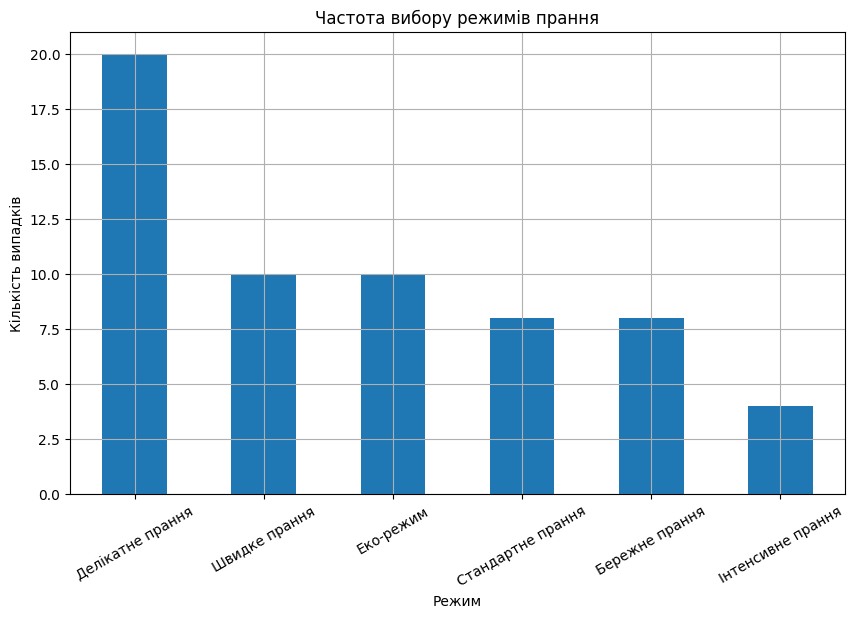

In [24]:
mode_counts = simulation_results["Режим"].value_counts()

plt.figure()
mode_counts.plot(kind="bar")
plt.title("Частота вибору режимів прання")
plt.xlabel("Режим")
plt.ylabel("Кількість випадків")
plt.xticks(rotation=30)
plt.show()

In [25]:
avg_by_class = simulation_results.groupby("Клас одягу")[["Температура", "Тривалість", "Вода"]].mean()
display(avg_by_class.round(2))

,Температура,Тривалість,Вода
Клас одягу,,,
Blazer,28.75,58.00,44.75
Celana_Panjang,35.00,88.75,76.25
Celana_Pendek,38.75,87.75,91.00
Gaun,27.50,84.75,70.25
Hoodie,38.75,88.50,79.75
Jaket,35.00,103.25,71.50
Jaket_Denim,45.00,74.25,79.25
Jaket_Olahraga,31.25,87.25,71.50
Jeans,46.25,93.50,82.75


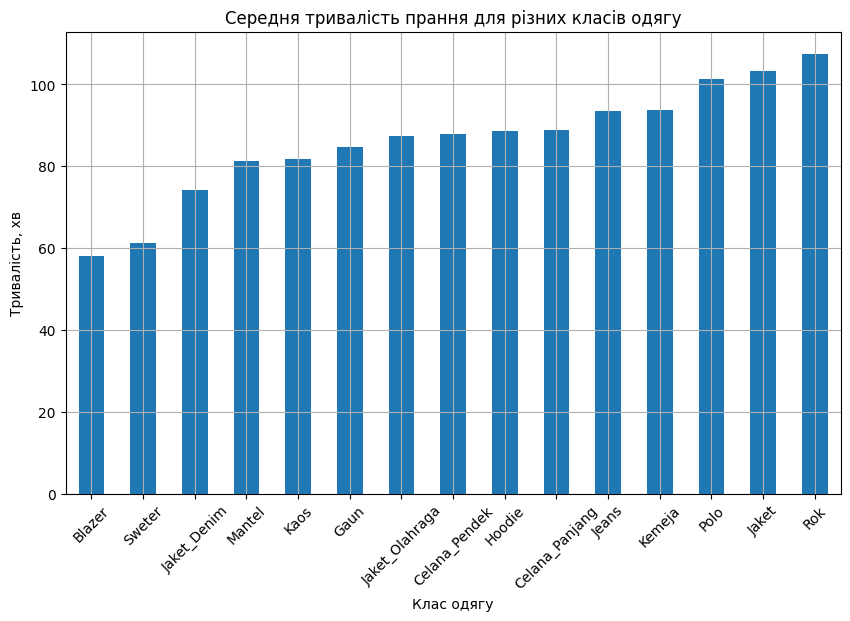

In [26]:
plt.figure()
avg_by_class["Тривалість"].sort_values().plot(kind="bar")
plt.title("Середня тривалість прання для різних класів одягу")
plt.xlabel("Клас одягу")
plt.ylabel("Тривалість, хв")
plt.xticks(rotation=45)
plt.show()

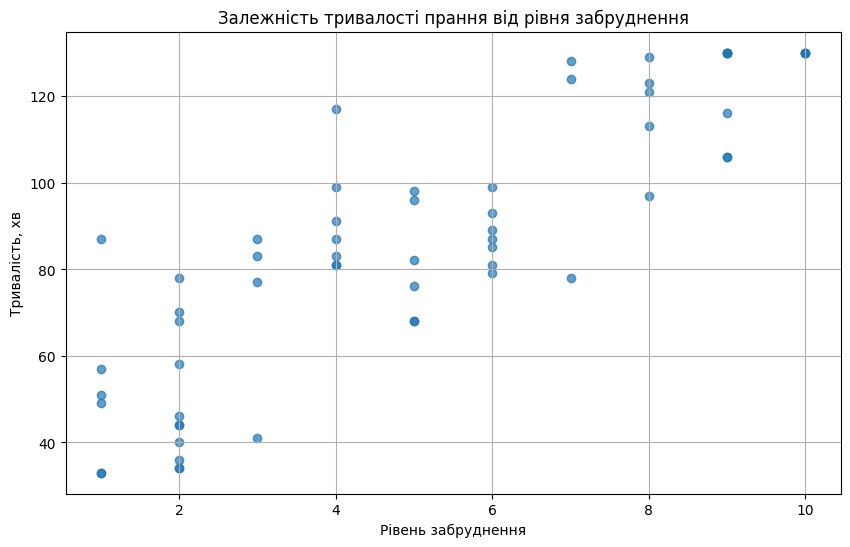

In [27]:
plt.figure()
plt.scatter(
    simulation_results["Забруднення"],
    simulation_results["Тривалість"],
    alpha=0.7
)
plt.title("Залежність тривалості прання від рівня забруднення")
plt.xlabel("Рівень забруднення")
plt.ylabel("Тривалість, хв")
plt.show()

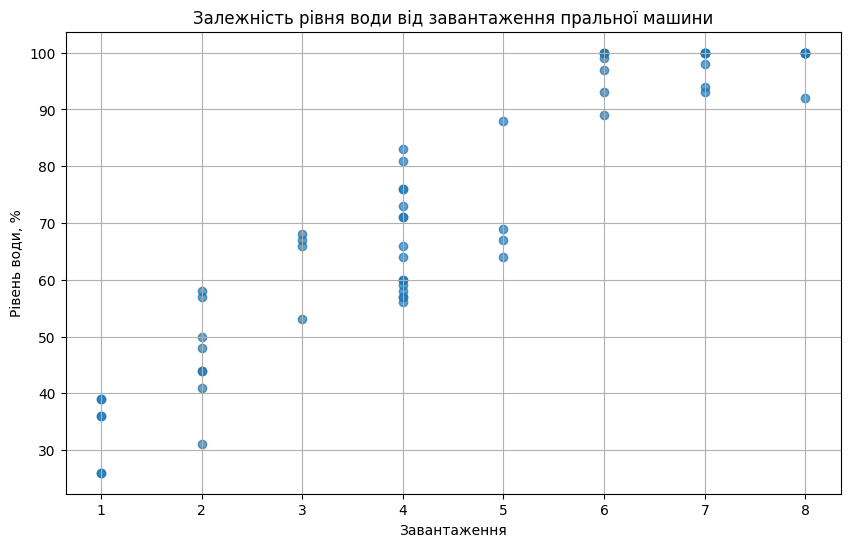

In [28]:
plt.figure()
plt.scatter(
    simulation_results["Завантаження"],
    simulation_results["Вода"],
    alpha=0.7
)
plt.title("Залежність рівня води від завантаження пральної машини")
plt.xlabel("Завантаження")
plt.ylabel("Рівень води, %")
plt.show()

## 6. Демонстраційний інтерфейс у Jupyter



In [29]:
dirt_options = {
    "Свіжий одяг після 1 носіння": 2,
    "Звичайне щоденне носіння": 4,
    "Помітні плями або запах": 7,
    "Сильно забруднений одяг": 9
}

load_options = {
    "Кілька речей": 2,
    "Половина барабана": 4,
    "Майже повний барабан": 6,
    "Повний барабан": 8
}

priority_options = [
    "Збалансовано",
    "Економія ресурсів",
    "Швидко випрати",
    "Максимально бережно"
]

In [ ]:
class_widget = widgets.Dropdown(
    options=dataset_agent.get_classes(),
    description="Тип одягу:",
    style={"description_width": "150px"},
    layout=widgets.Layout(width="450px")
)

image_widget = widgets.IntSlider(
    value=0,
    min=0,
    max=max(0, len(dataset_agent.get_images_by_class(class_widget.value)) - 1),
    step=1,
    description="Фото №:",
    style={"description_width": "150px"},
    layout=widgets.Layout(width="450px")
)

dirt_widget = widgets.Dropdown(
    options=list(dirt_options.keys()),
    description="Стан одягу:",
    style={"description_width": "150px"},
    layout=widgets.Layout(width="450px")
)

load_widget = widgets.Dropdown(
    options=list(load_options.keys()),
    description="Обсяг прання:",
    style={"description_width": "150px"},
    layout=widgets.Layout(width="450px")
)

priority_widget = widgets.Dropdown(
    options=priority_options,
    description="Пріоритет:",
    style={"description_width": "150px"},
    layout=widgets.Layout(width="450px")
)

button = widgets.Button(
    description="Підібрати режим",
    button_style="info",
    layout=widgets.Layout(width="220px")
)

preview_output = widgets.Output()
result_output = widgets.Output()


def show_preview(*args):
    with preview_output:
        clear_output(wait=True)

        images = dataset_agent.get_images_by_class(class_widget.value)
        if len(images) == 0:
            print("Для цього класу немає зображень.")
            return

        if image_widget.value >= len(images):
            image_widget.value = 0

        image_path = images[image_widget.value]
        info = clothes_info[class_widget.value]

        display(Image.open(image_path).resize((260, 260)))
        print("Клас із датасету:", class_widget.value)
        print("Категорія одягу:", info[0])
        print("Тип тканини за експертною таблицею:", info[1])


def update_image_slider(*args):
    images = dataset_agent.get_images_by_class(class_widget.value)
    image_widget.max = max(0, len(images) - 1)
    image_widget.value = 0
    show_preview()


def show_recommendation(button):
    with result_output:
        clear_output(wait=True)
        
        clothes_class, image_path = dataset_agent.get_item(
            class_widget.value,
            image_widget.value
        )
        
        analysis = analysis_agent.analyze(
            clothes_class=clothes_class,
            dirt_level=dirt_options[dirt_widget.value],
            load_size=load_options[load_widget.value],
            priority=priority_widget.value
        )
        
        decision = decision_agent.decide(analysis)
        
        display(widgets.HTML(f"""
        <div style="border: 1px solid #d0d0d0; border-radius: 12px; padding: 16px; width: 520px; background-color: #fafafa; font-family: Arial;">
            <h3 style="margin-top:0;">Рекомендація системи</h3>
            <p><b>Категорія одягу:</b> {analysis["clothes_name"]}</p>
            <p><b>Тип тканини за експертною таблицею:</b> {analysis["fabric"]}</p>
            <p><b>Стан одягу:</b> {dirt_widget.value}</p>
            <p><b>Обсяг прання:</b> {load_widget.value}</p>
            <p><b>Пріоритет:</b> {priority_widget.value}</p>
            <hr>
            <p><b>Режим:</b> {decision["mode"]}</p>
            <p><b>Температура:</b> {decision["temperature"]} °C</p>
            <p><b>Тривалість:</b> {decision["duration"]} хв</p>
            <p><b>Рівень води:</b> {decision["water"]} %</p>
            <p><b>Віджим:</b> {decision["spin"]} об/хв</p>
        </div>
        """))

        
class_widget.observe(update_image_slider, names="value")
image_widget.observe(show_preview, names="value")
button.on_click(show_recommendation)

show_preview()

display(
    widgets.VBox([
        widgets.HTML("<h3>Демонстраційний інтерфейс системи вибору режиму прання</h3>"),
        widgets.HTML("<p>Оберіть тип одягу та конкретне фото з датасету. Потім задайте побутову ситуацію для прання.</p>"),
        widgets.HBox([
            widgets.VBox([
                class_widget,
                image_widget,
                dirt_widget,
                load_widget,
                priority_widget,
                button
            ]),
            preview_output
        ]),
        result_output
    ])
)